In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
df_diff = pd.read_csv('../data/ab-test.csv')

df_diff = df_diff[df_diff['group'] == 'test'][['uid', 'diff']]
df_diff = df_diff.rename(columns={'diff': 'avg_diff'})
df_diff.head()

,uid,avg_diff
0,user_1,-103.333333
1,user_1,-6.000000
2,user_18,-10.000000
3,user_18,-3.500000
4,user_19,-82.333333


In [3]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

query_views = '''
SELECT 
    *
FROM
    pageviews
WHERE 
    uid LIKE 'user%'
'''

df_views = pd.read_sql_query(query_views, conn)
df_views = df_views.groupby('uid').count().reset_index()[['uid', 'index']]
df_views = df_views.rename(columns={'index': 'pageviews'})
df_views.head()

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3


In [4]:
query_commits = '''
SELECT
    *
FROM 
    checker
WHERE 
    uid LIKE 'user%' AND labname NOT IN ('project1')
'''

df_commits = pd.read_sql_query(query_commits, conn)
df_commits = df_commits.groupby('uid').count().reset_index()[['uid', 'index']]
df_commits = df_commits.rename(columns={'index': 'num_commits',})
df_commits.head()

,uid,num_commits
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86


In [5]:
df_all = df_diff.merge(df_views, on='uid', how='inner')
df_all = df_all.merge(df_commits, on='uid', how='inner')

df_all

,uid,avg_diff,pageviews,num_commits
0,user_1,-103.333333,28,62
1,user_1,-6.000000,28,62
2,user_18,-10.000000,3,5
3,user_18,-3.500000,3,5
4,user_19,-82.333333,16,118
5,user_19,-148.000000,16,118
6,user_21,-78.500000,10,65
7,user_21,-112.500000,10,65
8,user_25,-127.500000,179,79
9,user_25,-69.333333,179,79


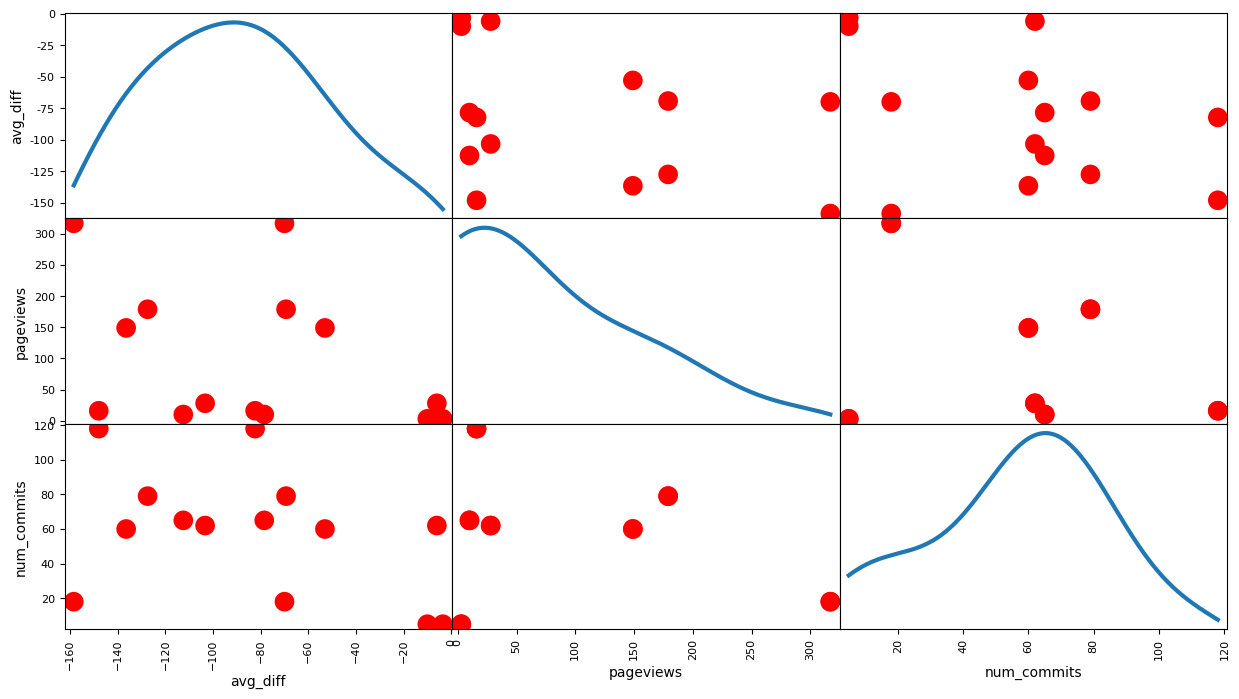

In [6]:
data = ['avg_diff', 'pageviews', 'num_commits']

axes = scatter_matrix(df_all[data], alpha=1, figsize=(15, 8), diagonal='kde', color='red', marker='o')

for ax in axes.flatten():
    for collection in ax.collections:
        collection.set_sizes([200])

    for line in ax.get_lines():
        line.set_linewidth(3)

In [7]:
conn.close()

## 1. Нет
## 2. Нет
## 3. Нет
## 4. Нет